---
#### 04-2. 직원 이직예측 모델
---

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cpu


---
#### Functions

In [19]:
# make dataset
def make_DataSet(X_train, X_val, y_train, y_val, batch_size=32):
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
  X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, X_val_tensor, y_val_tensor

# train
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  tr_loss = 0

  model.train()
  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    tr_loss += loss

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  tr_loss /= num_batches
  return tr_loss.item()

# evaluate
def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():
    X, y = X_val_tensor.to(device), y_val_tensor.to(device)
    pred = model(X)
    eval_loss = loss_fn(pred, y).item()
  return eval_loss, pred

# vizualize
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label='tr_err', marker='.')
  plt.plot(epochs, val_loss_list, label='val_err', marker='.')
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.legend()
  plt.grid()
  plt.show()

#### data loading and preprocessing

In [20]:
df = pd.read_csv('data/attri.csv')
print(df.shape)
display(df.head(2).T)

# target
y = df['Attrition']
X = df.drop(['Attrition', 'EmployeeNumber'], axis=1)

# one-hot encoding
cat_cols = ['Department','Education','EnvironmentSatisfaction','Gender',
            'JobSatisfaction', 'MaritalStatus', 'OverTime', 'WorkLifeBalance']

X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

# split validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# y -> numpy
y_train = y_train.values
y_val = y_val.values

(1175, 19)


,0,1
Attrition,0,0
Age,33,35
Department,Research & Development,Research & Development
DistanceFromHome,7,18
Education,3,2
EmployeeNumber,817,1412
EnvironmentSatisfaction,3,3
Gender,Male,Male
JobSatisfaction,3,4
MaritalStatus,Married,Single


#### modeling

In [21]:
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, 32)

from torchsummary import summary
model = nn.Sequential(
    nn.Linear(X.shape[1],16),
    nn.ReLU(),
    nn.Linear(16,8),
    nn.ReLU(),
    nn.Linear(8,1),
    nn.Sigmoid()
).to(device)

summary(model, input_size=(X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             464
              ReLU-2                   [-1, 16]               0
            Linear-3                    [-1, 8]             136
              ReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
           Sigmoid-6                    [-1, 1]               0
Total params: 609
Trainable params: 609
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [22]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.001)

#### train, eval

In [23]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"epoch {i}, train loss: {tr_loss:.4f}, val loss: {val_loss:.4f}")

epoch 0, train loss: 0.7893, val loss: 0.7576
epoch 1, train loss: 0.7162, val loss: 0.6645
epoch 2, train loss: 0.5981, val loss: 0.5149
epoch 3, train loss: 0.4757, val loss: 0.4433
epoch 4, train loss: 0.4496, val loss: 0.4329
epoch 5, train loss: 0.4354, val loss: 0.4271
epoch 6, train loss: 0.4303, val loss: 0.4221
epoch 7, train loss: 0.4292, val loss: 0.4167
epoch 8, train loss: 0.4257, val loss: 0.4117
epoch 9, train loss: 0.4036, val loss: 0.4072
epoch 10, train loss: 0.3929, val loss: 0.4030
epoch 11, train loss: 0.3846, val loss: 0.3989
epoch 12, train loss: 0.3832, val loss: 0.3958
epoch 13, train loss: 0.3777, val loss: 0.3926
epoch 14, train loss: 0.3699, val loss: 0.3910
epoch 15, train loss: 0.3667, val loss: 0.3895
epoch 16, train loss: 0.3717, val loss: 0.3894
epoch 17, train loss: 0.3554, val loss: 0.3886
epoch 18, train loss: 0.3543, val loss: 0.3884
epoch 19, train loss: 0.3605, val loss: 0.3877
epoch 20, train loss: 0.3488, val loss: 0.3881
epoch 21, train loss: 0

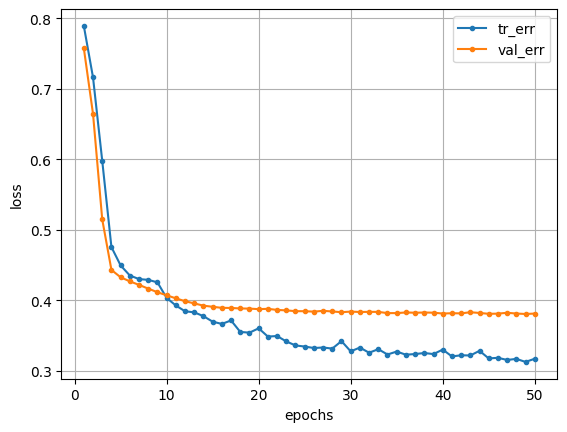

In [24]:
learning_curve(tr_loss_list, val_loss_list)

In [25]:
_, pred = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)
pred = np.where(pred.numpy() >0.5, 1,0)

print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92       197
         1.0       0.61      0.29      0.39        38

    accuracy                           0.86       235
   macro avg       0.74      0.63      0.66       235
weighted avg       0.83      0.86      0.83       235

